# Example usage of `run_agent_env_sensor_loop`

This notebook shows a minimal, end-to-end call to `run_agent_env_sensor_loop`, including:
- setting sensor and specification parameters
- choosing whether to use pure PID or EKF+PID
- saving and viewing the trajectory plot

In [1]:
from pathlib import Path

# Ensure notebook is running from project root
project_root = Path.cwd()
project_root

PosixPath('/Users/andrewzchen/S-Senior/Winter Quarter/CS 238V/aa228v_finalproject')

In [2]:
import numpy as np
from main import run_agent_env_sensor_loop

In [ ]:
sensor_args = dict(
    # Wave amplitude
    mu_A=0.1,
    sigma_A=0.05,
    # Wave wavenumber
    mu_k=2 * np.pi,
    sigma_k=0.5,
    # Vibration
    sigma_eps=0.01,
    # LiDAR penetration
    p_penetration=0.05,
    alpha_min=0.10,
    alpha_max=10.0,
    perfect_sensing=True,  # IMPORTANT: toggle to turn on/off sensor noise
)

specification = dict(
    z_min=0.1,
    z_max=1.0,
    pitch_min=-np.deg2rad(15.0),
    pitch_max=np.deg2rad(15.0),
)

trajectory_path = "plots/plane_trajectory_notebook.png"

In [14]:
result = run_agent_env_sensor_loop(
    z0=0.5,
    z_target=0.5,
    n_steps=2000,  # dt = 0.01 s
    seed=42,
    enable_lateral_damper=True,  # fixes lateral instability using aileron
    use_ekf_pid_controller=True,  # set False to run pure PID
    sensor_args=sensor_args,
    specification=specification,
    ground_effect_enabled=True,
    save_trajectory_plot=True,
    trajectory_plot_path=trajectory_path,
)

result

 step    z_true     z_hat    de_pid    de_ekf    da_ekf     z_est   theta_est
------------------------------------------------------------------------
Controller driving env.step: EKF+PID
    0    0.5000    0.5000    0.0000    0.0000   -0.0000    0.5000     0.00000
   20    0.4999    0.4999   -0.0503   -0.0504    0.0014    0.5001     0.02507
   40    0.5666    0.5666   -0.0912   -0.0913    0.0031    0.5667     0.03177
   60    0.6300    0.6300   -0.0944   -0.0944    0.0042    0.6301     0.01997
   80    0.6492    0.6492   -0.0783   -0.0784    0.0046    0.6493     0.00741
  100    0.6341    0.6341   -0.0644   -0.0644    0.0046    0.6343     0.00282
  120    0.6127    0.6127   -0.0610   -0.0611    0.0044    0.6129     0.00489
  140    0.6025    0.6025   -0.0651   -0.0652    0.0041    0.6026     0.00847
  160    0.6038    0.6038   -0.0699   -0.0700    0.0040    0.6040     0.01008
  180    0.6088    0.6088   -0.0718   -0.0718    0.0042    0.6090     0.00948
  200    0.6112    0.6112   -0.0

{'terminated_early': False,
 'termination_step': None,
 'termination_type': None,
 'termination_message': None,
 'violated_spec': None,
 'final_state': array([ 5.42019535e-01, -3.19039009e-02,  4.28573810e+02,  2.38689305e+01,
         1.40422960e-03, -1.13538968e-04]),
 'used_ekf_pid': True,
 'specification': {'z_min': 0.1,
  'z_max': 1.0,
  'pitch_min': np.float64(-0.2617993877991494),
  'pitch_max': np.float64(0.2617993877991494)},
 'trajectory_plot': {'saved': True,
  'path': 'plots/plane_trajectory_notebook.png',
  'num_points': 2001}}

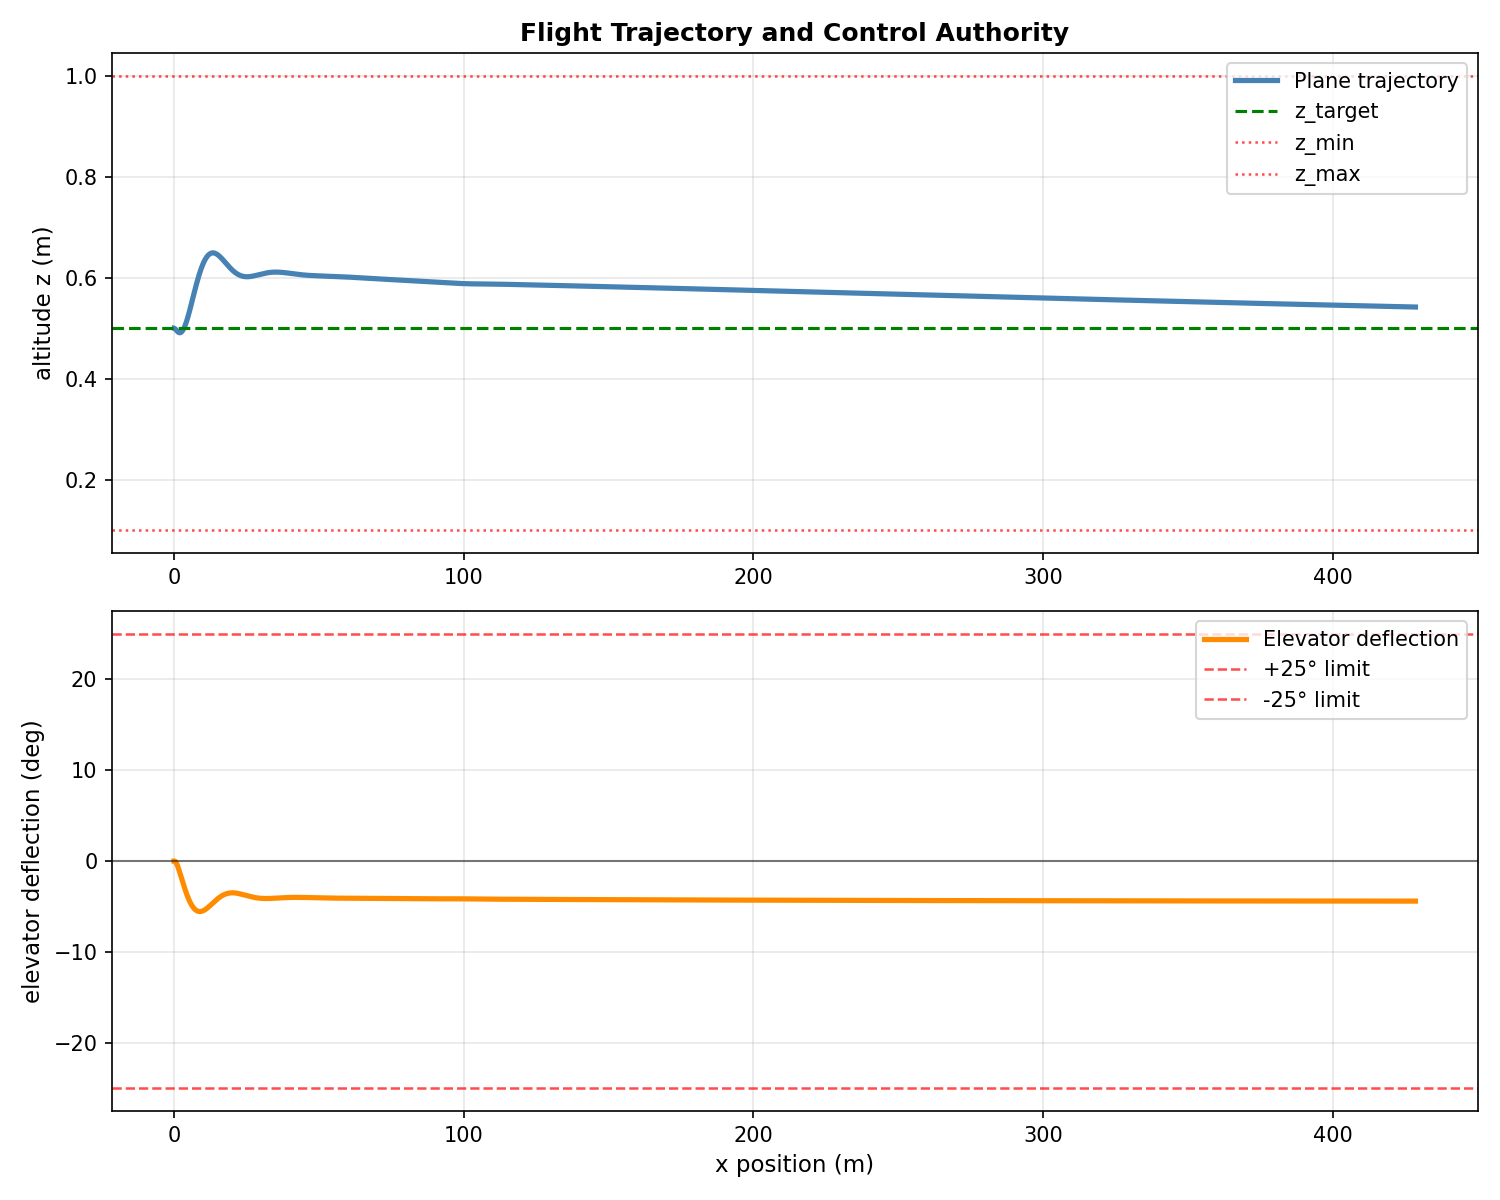

In [15]:
from IPython.display import Image, display

if result.get("trajectory_plot", {}).get("saved", False):
    display(Image(filename=result["trajectory_plot"]["path"]))
else:
    print("Trajectory plot was not saved.")
    print(result.get("trajectory_plot"))